In [1]:
# Principle: Minimising Complexity, Reuse (COTS assets)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import brentq
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve,
                              average_precision_score, f1_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports successful")

Imports successful


In [2]:
# Principle: Anticipating Change, SPE Classification
print("""
Project: Alternative Credit Scoring System — Cameroonian Vendors
Output:  APPROVE | REVIEW | REJECT

SPE Classification:
  S-Type: validate_schema(), engineer_features()
  P-Type: model training pipeline
  E-Type: credit_decision(), fairness_audit(), full deployed system
""")


Project: Alternative Credit Scoring System — Cameroonian Vendors
Output:  APPROVE | REVIEW | REJECT

SPE Classification:
  S-Type: validate_schema(), engineer_features()
  P-Type: model training pipeline
  E-Type: credit_decision(), fairness_audit(), full deployed system



In [4]:
# Principle: Constructing for Verification, Managing Complexity
# READS:  ../data/alt_data.csv
# SAVES:  ../data/alt_data_expanded.csv

RAW_PATH      = "../data/alt_data_expanded.csv"
EXPANDED_PATH = "../data/alt_data_expanded.csv"

df_orig    = pd.read_csv(RAW_PATH)
N_ORIG     = len(df_orig)
N_SYNTH    = 3600
TARGET_DR  = df_orig['loan_defaulted'].mean()

print(f"Original: {N_ORIG} records | Default rate: {TARGET_DR:.3f}")

gp = df_orig['gender'].value_counts(normalize=True)
rp = df_orig['region'].value_counts(normalize=True)
bp = df_orig['business_type'].value_counts(normalize=True)

gender = np.random.choice(gp.index, N_SYNTH, p=gp.values)
region = np.random.choice(rp.index, N_SYNTH, p=rp.values)
btype  = np.random.choice(bp.index, N_SYNTH, p=bp.values)

age               = np.random.randint(21, 65, N_SYNTH)
years_in_business = np.clip(np.round(np.random.exponential(3.0, N_SYNTH)).astype(int), 0, 25)

lr_mean  = np.log(df_orig['monthly_revenue_xaf']).mean()
lr_std   = np.log(df_orig['monthly_revenue_xaf']).std()
revenue  = np.clip(np.random.lognormal(lr_mean, lr_std, N_SYNTH), 8000, 700000).round(0)

er_mean  = (df_orig['monthly_expenses_xaf'] / df_orig['monthly_revenue_xaf']).mean()
er_std   = (df_orig['monthly_expenses_xaf'] / df_orig['monthly_revenue_xaf']).std()
expenses = (revenue * np.clip(np.random.normal(er_mean, er_std, N_SYNTH), 0.30, 0.95)).round(0)

profit   = np.random.uniform(0.15, 0.50, N_SYNTH).round(2)
txn      = np.clip(np.round(np.random.normal(44.97, 6.91, N_SYNTH)).astype(int), 25, 69)

wb_mean  = np.log(df_orig['avg_wallet_balance_xaf']).mean()
wb_std   = np.log(df_orig['avg_wallet_balance_xaf']).std()
wallet   = np.clip(np.random.lognormal(wb_mean, wb_std, N_SYNTH), 3000, 250000).round(0)

utility  = np.random.binomial(1, 0.696, N_SYNTH)
supplier = np.random.binomial(1, 0.545, N_SYNTH)
noise    = np.random.normal(0, 0.3, N_SYNTH)

def combined_rate(intercept):
    lo = intercept - 0.7*utility - 0.45*supplier - 1.2*profit - 0.05*years_in_business + noise
    p  = 1 / (1 + np.exp(-lo))
    return (N_ORIG * TARGET_DR + N_SYNTH * p.mean()) / (N_ORIG + N_SYNTH) - TARGET_DR

opt  = brentq(combined_rate, 0.5, 3.0)
lo   = opt - 0.7*utility - 0.45*supplier - 1.2*profit - 0.05*years_in_business + noise
defaulted = np.random.binomial(1, 1 / (1 + np.exp(-lo)))

cs_raw = (420
          + utility   * np.random.normal(70, 15, N_SYNTH)
          + supplier  * np.random.normal(50, 12, N_SYNTH)
          + profit    * np.random.normal(200, 30, N_SYNTH)
          + years_in_business * np.random.normal(5, 2, N_SYNTH)
          + np.random.normal(0, 30, N_SYNTH))
cs = np.clip(np.round(cs_raw).astype(int), 300, 850)

synth = pd.DataFrame({
    'vendor_id': range(N_ORIG+1, N_ORIG+N_SYNTH+1),
    'age': age, 'gender': gender, 'region': region,
    'business_type': btype, 'years_in_business': years_in_business,
    'monthly_revenue_xaf': revenue, 'monthly_expenses_xaf': expenses,
    'profit_margin': profit, 'mobile_money_txn_count': txn,
    'avg_wallet_balance_xaf': wallet, 'utility_payment_score': utility,
    'supplier_credit_history': supplier, 'credit_score': cs,
    'loan_defaulted': defaulted,
})

df = pd.concat([df_orig, synth], ignore_index=True)
df['vendor_id'] = range(1, len(df)+1)
df.to_csv(EXPANDED_PATH, index=False)

print(f"Expanded: {len(df):,} records")
print(f"Default rate — original: {TARGET_DR:.3f} | combined: {df['loan_defaulted'].mean():.3f}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Saved -> {EXPANDED_PATH}")

Original: 5100 records | Default rate: 0.551
Expanded: 8,700 records
Default rate — original: 0.551 | combined: 0.553
Missing values: 0
Saved -> ../data/alt_data_expanded.csv


In [5]:
# Principle: S-Type Component, Constructing for Verification

def validate_schema(df):
    violations = []
    required = [
        'age','gender','region','business_type','years_in_business',
        'monthly_revenue_xaf','monthly_expenses_xaf','profit_margin',
        'mobile_money_txn_count','avg_wallet_balance_xaf',
        'utility_payment_score','supplier_credit_history',
        'credit_score','loan_defaulted'
    ]
    for col in required:
        if col not in df.columns:
            violations.append(f"MISSING: {col}")
    if 'age' in df.columns and (df['age'].min() < 18 or df['age'].max() > 80):
        violations.append("age out of range [18, 80]")
    if 'profit_margin' in df.columns and not (0 <= df['profit_margin'].min() and df['profit_margin'].max() <= 1):
        violations.append("profit_margin out of range [0, 1]")
    if 'monthly_revenue_xaf' in df.columns and df['monthly_revenue_xaf'].min() < 0:
        violations.append("monthly_revenue_xaf has negative values")
    for col in ['utility_payment_score','supplier_credit_history','loan_defaulted']:
        if col in df.columns and not df[col].isin([0,1]).all():
            violations.append(f"{col} is not binary")
    return violations

result = validate_schema(df)
print(f"Schema validation: {'PASSED' if not result else 'FAILED: ' + str(result)}")

Schema validation: PASSED


Records: 8,700 | Default rate: 0.553

By gender:
gender
Female    0.558
Male      0.548
Name: loan_defaulted, dtype: float64

By region:
region
Centre        0.543
Far North     0.548
Littoral      0.554
North West    0.539
South West    0.593
West          0.547
Name: loan_defaulted, dtype: float64

By business type:
business_type
Agriculture      0.553
Manufacturing    0.513
Retail           0.553
Services         0.564
Transport        0.550
Name: loan_defaulted, dtype: float64


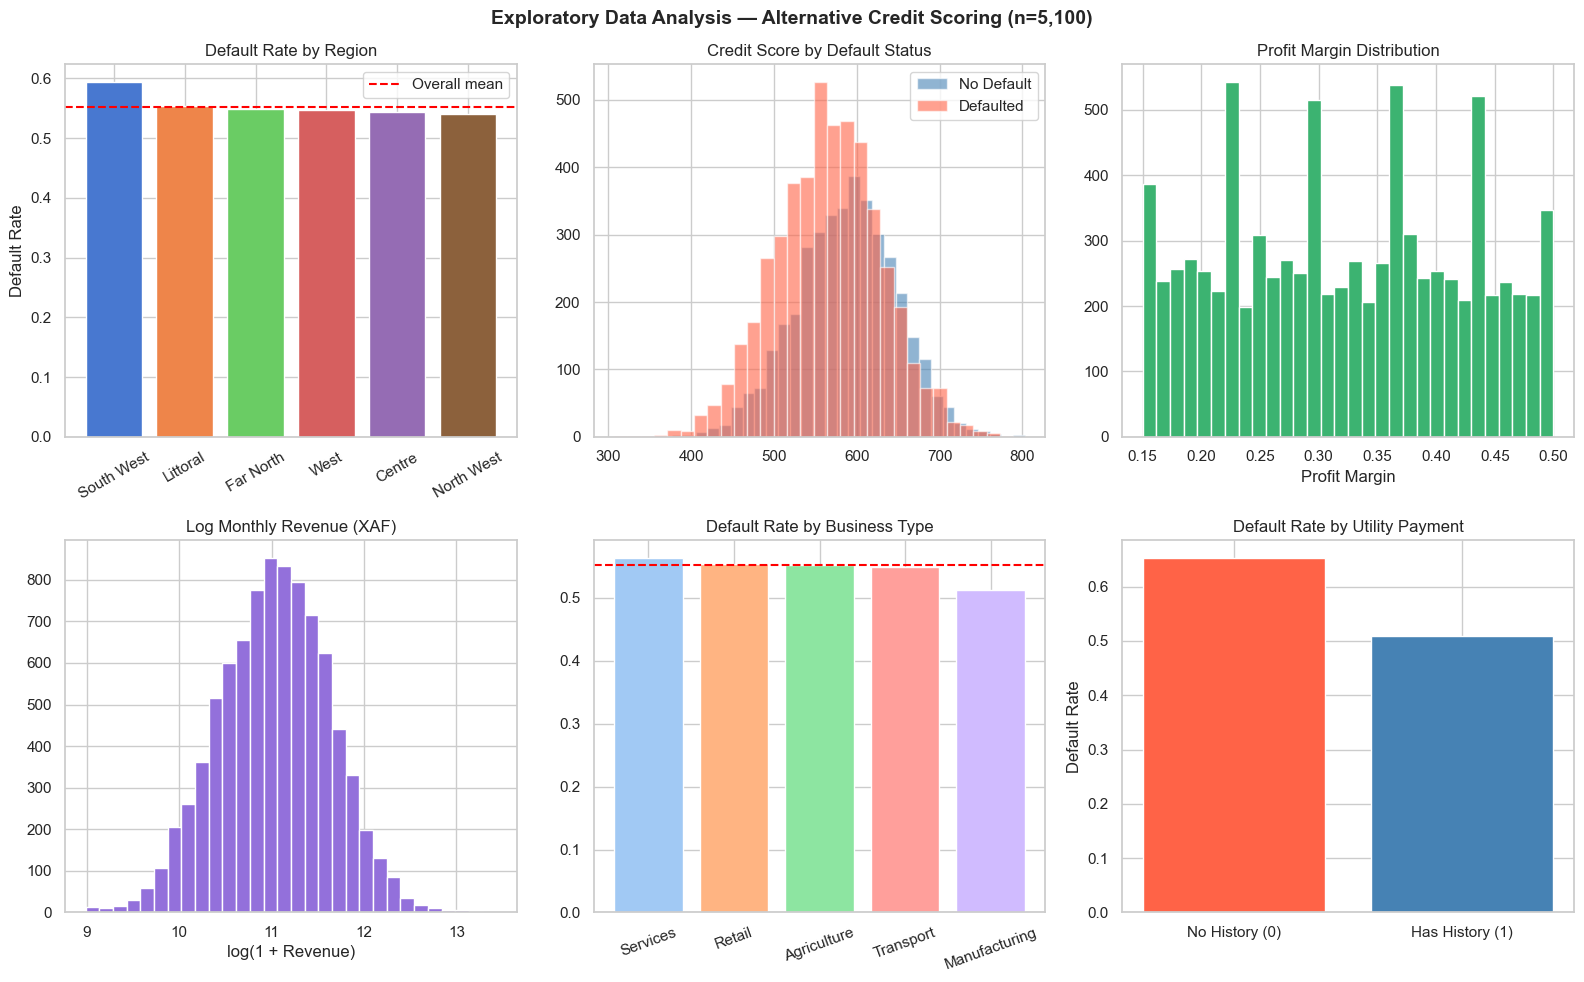

Saved -> ../outputs/eda_analysis.png


In [7]:
# Principle: Managing Complexity
# SAVES: ../outputs/eda_analysis.png

EDA_PATH = "../outputs/eda_analysis.png"

print(f"Records: {len(df):,} | Default rate: {df['loan_defaulted'].mean():.3f}")
print(f"\nBy gender:\n{df.groupby('gender')['loan_defaulted'].mean().round(3)}")
print(f"\nBy region:\n{df.groupby('region')['loan_defaulted'].mean().round(3)}")
print(f"\nBy business type:\n{df.groupby('business_type')['loan_defaulted'].mean().round(3)}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis — Alternative Credit Scoring (n=5,100)",
             fontsize=14, fontweight='bold')

dr = df.groupby('region')['loan_defaulted'].mean().sort_values(ascending=False)
axes[0,0].bar(dr.index, dr.values, color=sns.color_palette("muted", len(dr)))
axes[0,0].axhline(df['loan_defaulted'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0,0].set_title("Default Rate by Region"); axes[0,0].set_ylabel("Default Rate")
axes[0,0].tick_params(axis='x', rotation=30); axes[0,0].legend()

axes[0,1].hist(df[df['loan_defaulted']==0]['credit_score'], bins=30, alpha=0.6, label='No Default', color='steelblue')
axes[0,1].hist(df[df['loan_defaulted']==1]['credit_score'], bins=30, alpha=0.6, label='Defaulted', color='tomato')
axes[0,1].set_title("Credit Score by Default Status"); axes[0,1].legend()

axes[0,2].hist(df['profit_margin'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title("Profit Margin Distribution"); axes[0,2].set_xlabel("Profit Margin")

axes[1,0].hist(np.log1p(df['monthly_revenue_xaf']), bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].set_title("Log Monthly Revenue (XAF)"); axes[1,0].set_xlabel("log(1 + Revenue)")

db = df.groupby('business_type')['loan_defaulted'].mean().sort_values(ascending=False)
axes[1,1].bar(db.index, db.values, color=sns.color_palette("pastel", len(db)))
axes[1,1].axhline(df['loan_defaulted'].mean(), color='red', linestyle='--')
axes[1,1].set_title("Default Rate by Business Type"); axes[1,1].tick_params(axis='x', rotation=20)

ud = df.groupby('utility_payment_score')['loan_defaulted'].mean()
axes[1,2].bar(['No History (0)','Has History (1)'], ud.values, color=['tomato','steelblue'])
axes[1,2].set_title("Default Rate by Utility Payment"); axes[1,2].set_ylabel("Default Rate")

plt.tight_layout()
plt.savefig(EDA_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {EDA_PATH}")

In [8]:
# Principle: S-Type Component, Abstraction and Decomposition

def engineer_features(df):
    """
    S-Type: pure function, deterministic, no side effects.
    Transformations:
      expense_ratio      = monthly_expenses / monthly_revenue
      business_stability = 1 if years_in_business >= 3 else 0
      log_revenue        = log(1 + monthly_revenue_xaf)
      log_wallet_balance = log(1 + avg_wallet_balance_xaf)
    """
    df = df.copy()
    df['expense_ratio']      = df['monthly_expenses_xaf'] / df['monthly_revenue_xaf']
    df['business_stability'] = (df['years_in_business'] >= 3).astype(int)
    df['log_revenue']        = np.log1p(df['monthly_revenue_xaf'])
    df['log_wallet_balance'] = np.log1p(df['avg_wallet_balance_xaf'])
    return df

def encode_categoricals(df):
    """S-Type: deterministic encoding, returns encoders for reuse on new data."""
    df = df.copy()
    encoders = {}
    for raw, enc in [('gender','gender_enc'),('region','region_enc'),('business_type','btype_enc')]:
        le = LabelEncoder()
        df[enc] = le.fit_transform(df[raw])
        encoders[raw] = le
    return df, encoders

df, encoders = encode_categoricals(engineer_features(df))

print("Features added: expense_ratio | business_stability | log_revenue | log_wallet_balance")
print("Encoded: gender_enc | region_enc | btype_enc")

Features added: expense_ratio | business_stability | log_revenue | log_wallet_balance
Encoded: gender_enc | region_enc | btype_enc


In [11]:
# Principle: Constructing for Verification, Managing Complexity

FEATURES = [
    'credit_score', 'expense_ratio', 'profit_margin',
    'years_in_business', 'mobile_money_txn_count',
    'utility_payment_score', 'supplier_credit_history',
    'business_stability', 'log_revenue', 'log_wallet_balance',
    'gender_enc', 'region_enc', 'btype_enc', 'age'
]

X = df[FEATURES]
y = df['loan_defaulted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.3f} | Test default rate: {y_test.mean():.3f}")

Train: 6,960 | Test: 1,740
Train default rate: 0.553 | Test default rate: 0.552


In [12]:
# Principle: P-Type Component, Anticipating Change (models swappable)
# Three models:
#   Logistic Regression — interpretable, regulatory-friendly
#   Random Forest       — handles non-linearity, robust to outliers
#   XGBoost             — strong performance on tabular data

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_model.fit(X_train_sc, y_train)
lr_cv    = cross_val_score(lr_model, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()
lr_prob  = lr_model.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr_model.predict(X_test_sc)
print(f"  CV AUC: {lr_cv:.4f}")

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_cv   = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)
print(f"  CV AUC: {rf_cv:.4f}")

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_cv   = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
print(f"  CV AUC: {xgb_cv:.4f}")

Training Logistic Regression...
  CV AUC: 0.6167
Training Random Forest...
  CV AUC: 0.6840
Training XGBoost...
  CV AUC: 0.7224


Model                       Test AUC     CV AUC   Avg Prec   Accuracy       F1
---------------------------------------------------------------------------
Logistic Regression           0.6088     0.6167     0.6562     0.5799   0.6494
Random Forest                 0.6878     0.6840     0.7271     0.6259   0.6904
XGBoost                       0.7414     0.7224     0.7656     0.6770   0.7272

Best model: XGBoost (AUC = 0.7414)

Detailed report — XGBoost:
              precision    recall  f1-score   support

  No Default       0.67      0.55      0.60       779
   Defaulted       0.68      0.78      0.73       961

    accuracy                           0.68      1740
   macro avg       0.68      0.67      0.67      1740
weighted avg       0.68      0.68      0.67      1740



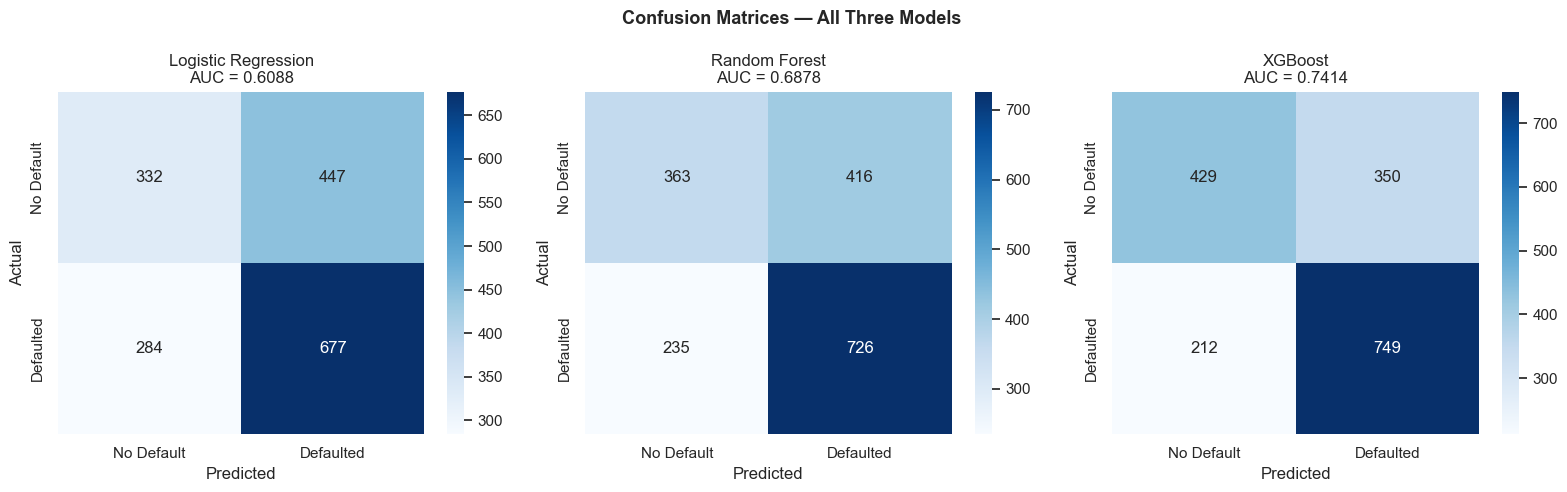

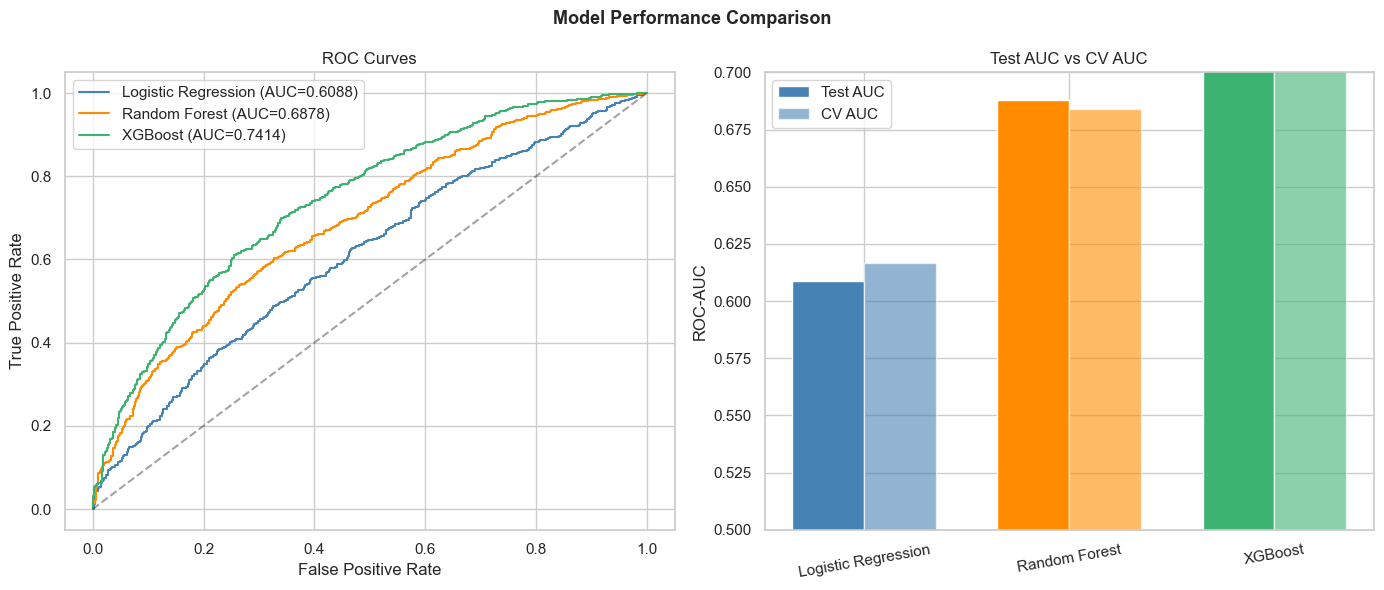

Saved -> ../outputs/confusion_matrices.png
Saved -> ../outputs/roc_comparison.png


In [13]:
# Principle: P-Type Evaluation, Constructing for Verification
# SAVES: ../outputs/confusion_matrices.png
#        ../outputs/roc_comparison.png

CONFUSION_PATH = "../outputs/confusion_matrices.png"
ROC_PATH       = "../outputs/roc_comparison.png"

print(f"{'Model':<25} {'Test AUC':>10} {'CV AUC':>10} {'Avg Prec':>10} {'Accuracy':>10} {'F1':>8}")
print("-" * 75)

results = {}
for name, prob, pred, cv_auc, model, scaled in [
    ("Logistic Regression", lr_prob,  lr_pred,  lr_cv,  lr_model,  True),
    ("Random Forest",       rf_prob,  rf_pred,  rf_cv,  rf_model,  False),
    ("XGBoost",             xgb_prob, xgb_pred, xgb_cv, xgb_model, False),
]:
    auc = roc_auc_score(y_test, prob)
    ap  = average_precision_score(y_test, prob)
    acc = (pred == y_test).mean()
    f1  = f1_score(y_test, pred)
    results[name] = dict(prob=prob, pred=pred, cv_auc=cv_auc, test_auc=auc,
                         ap=ap, acc=acc, f1=f1, model=model, needs_scaling=scaled)
    print(f"{name:<25} {auc:>10.4f} {cv_auc:>10.4f} {ap:>10.4f} {acc:>10.4f} {f1:>8.4f}")

best_name = max(results, key=lambda n: results[n]['test_auc'])
best_auc  = results[best_name]['test_auc']
print(f"\nBest model: {best_name} (AUC = {best_auc:.4f})")

print(f"\nDetailed report — {best_name}:")
print(classification_report(y_test, results[best_name]['pred'],
                             target_names=['No Default','Defaulted']))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — All Three Models", fontsize=13, fontweight='bold')
colors3 = ['steelblue', 'darkorange', 'mediumseagreen']
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default','Defaulted'],
                yticklabels=['No Default','Defaulted'])
    ax.set_title(f"{name}\nAUC = {res['test_auc']:.4f}")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(CONFUSION_PATH, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Performance Comparison", fontsize=13, fontweight='bold')
for (name, res), color in zip(results.items(), colors3):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.4f})", color=color)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend()

x = np.arange(len(results)); w = 0.35
axes[1].bar(x-w/2, [r['test_auc'] for r in results.values()], w, label='Test AUC', color=colors3)
axes[1].bar(x+w/2, [r['cv_auc']   for r in results.values()], w, label='CV AUC',   color=colors3, alpha=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels(list(results.keys()), rotation=10)
axes[1].set_ylim(0.50, 0.70); axes[1].legend()
axes[1].set_title("Test AUC vs CV AUC"); axes[1].set_ylabel("ROC-AUC")
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {CONFUSION_PATH}")
print(f"Saved -> {ROC_PATH}")

Calibrated AUC (XGBoost): 0.7443


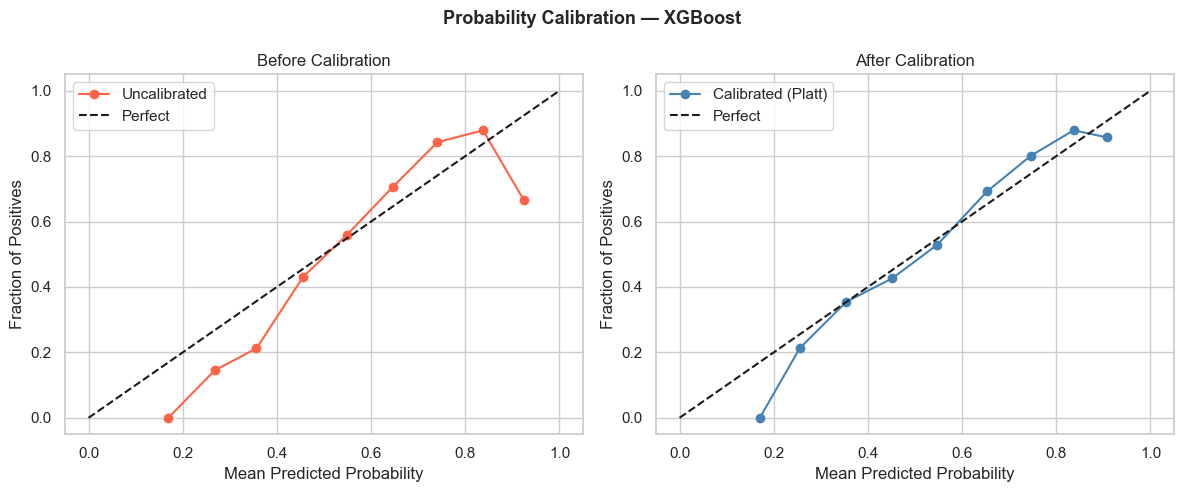

Saved -> ../outputs/calibration.png


In [14]:
# Principle: P-Type to E-Type boundary, Constructing for Verification
# SAVES: ../outputs/calibration.png

CALIB_PATH = "../outputs/calibration.png"

best_res = results[best_name]
needs_sc = best_res['needs_scaling']

calib_model = CalibratedClassifierCV(best_res['model'], method='sigmoid', cv=5)
if needs_sc:
    calib_model.fit(X_train_sc, y_train)
    calib_prob = calib_model.predict_proba(X_test_sc)[:, 1]
else:
    calib_model.fit(X_train, y_train)
    calib_prob = calib_model.predict_proba(X_test)[:, 1]

print(f"Calibrated AUC ({best_name}): {roc_auc_score(y_test, calib_prob):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Probability Calibration — {best_name}", fontsize=13, fontweight='bold')

pt1, pp1 = calibration_curve(y_test, best_res['prob'], n_bins=10)
axes[0].plot(pp1, pt1, 'o-', color='tomato', label='Uncalibrated')
axes[0].plot([0,1],[0,1],'k--', label='Perfect'); axes[0].legend()
axes[0].set_title("Before Calibration")
axes[0].set_xlabel("Mean Predicted Probability"); axes[0].set_ylabel("Fraction of Positives")

pt2, pp2 = calibration_curve(y_test, calib_prob, n_bins=10)
axes[1].plot(pp2, pt2, 'o-', color='steelblue', label='Calibrated (Platt)')
axes[1].plot([0,1],[0,1],'k--', label='Perfect'); axes[1].legend()
axes[1].set_title("After Calibration")
axes[1].set_xlabel("Mean Predicted Probability"); axes[1].set_ylabel("Fraction of Positives")

plt.tight_layout()
plt.savefig(CALIB_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {CALIB_PATH}")

In [15]:
# Principle: E-Type Component, Anticipating Change (configurable thresholds)

THRESHOLDS = {
    'approve_below': 0.45,
    'review_below':  0.65,
}

def credit_decision(prob, thresholds=THRESHOLDS):
    """E-Type: maps calibrated probability to lending decision."""
    if prob < thresholds['approve_below']:  return 'APPROVE'
    elif prob < thresholds['review_below']: return 'REVIEW'
    else:                                   return 'REJECT'

def probability_to_score(prob):
    """S-Type: score = clip(850 - (prob * 550), 300, 850)"""
    return int(np.clip(850 - (prob * 550), 300, 850))

test_df = X_test.copy()
test_df['calibrated_default_prob'] = calib_prob
test_df['credit_score_output']     = pd.Series(calib_prob, index=X_test.index).apply(probability_to_score)
test_df['decision']                = pd.Series(calib_prob, index=X_test.index).apply(credit_decision)
test_df['gender']                  = df.loc[X_test.index, 'gender']
test_df['actual_default']          = y_test.values

print("Decision distribution (test set):")
print(test_df['decision'].value_counts(normalize=True).round(3))
print(f"\nCredit score: mean={test_df['credit_score_output'].mean():.0f}, "
      f"std={test_df['credit_score_output'].std():.0f}, "
      f"range=[{test_df['credit_score_output'].min()}, {test_df['credit_score_output'].max()}]")

Decision distribution (test set):
REVIEW     0.367
REJECT     0.328
APPROVE    0.305
Name: decision, dtype: float64

Credit score: mean=548, std=97, range=[346, 794]


Decision rates by gender:
decision  APPROVE  REJECT  REVIEW
gender                           
Female      0.285   0.331   0.384
Male        0.321   0.326   0.353

Approval — Male: 0.321 | Female: 0.285
Gender gap: 0.036  Within acceptable range

Mean default probability by region:
region
North West    0.532
West          0.544
Littoral      0.546
Centre        0.546
Far North     0.547
South West    0.581
Name: calibrated_default_prob, dtype: float64


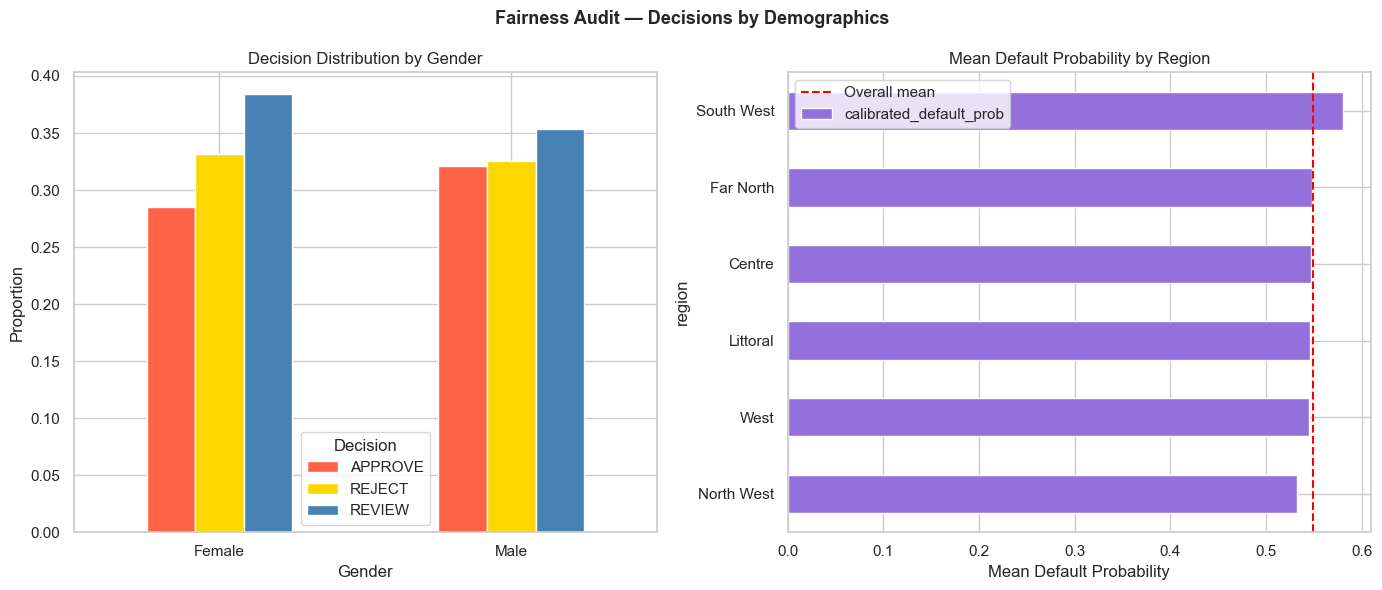

Saved -> ../outputs/fairness_audit.png


In [16]:
# Principle: E-Type Component, Corrective and Preventive Change
# SAVES: ../outputs/fairness_audit.png

FAIRNESS_PATH = "../outputs/fairness_audit.png"

gender_dec = (test_df.groupby('gender')['decision']
              .value_counts(normalize=True).unstack(fill_value=0))
print("Decision rates by gender:")
print(gender_dec.round(3))

if 'APPROVE' in gender_dec.columns:
    m_app = gender_dec.loc['Male',   'APPROVE'] if 'Male'   in gender_dec.index else 0
    f_app = gender_dec.loc['Female', 'APPROVE'] if 'Female' in gender_dec.index else 0
    gap   = abs(m_app - f_app)
    print(f"\nApproval — Male: {m_app:.3f} | Female: {f_app:.3f}")
    print(f"Gender gap: {gap:.3f}  {'MONITOR — exceeds 5% threshold' if gap > 0.05 else 'Within acceptable range'}")

test_df_r           = test_df.copy()
test_df_r['region'] = df.loc[X_test.index, 'region'].values
region_prob = test_df_r.groupby('region')['calibrated_default_prob'].mean().sort_values()
print(f"\nMean default probability by region:\n{region_prob.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fairness Audit — Decisions by Demographics", fontsize=13, fontweight='bold')

gender_dec.plot(kind='bar', ax=axes[0],
                color=['tomato','gold','steelblue'], edgecolor='white')
axes[0].set_title("Decision Distribution by Gender")
axes[0].set_xlabel("Gender"); axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=0); axes[0].legend(title='Decision')

region_prob.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].axvline(test_df['calibrated_default_prob'].mean(),
                color='red', linestyle='--', label='Overall mean')
axes[1].set_title("Mean Default Probability by Region")
axes[1].set_xlabel("Mean Default Probability"); axes[1].legend()

plt.tight_layout()
plt.savefig(FAIRNESS_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FAIRNESS_PATH}")

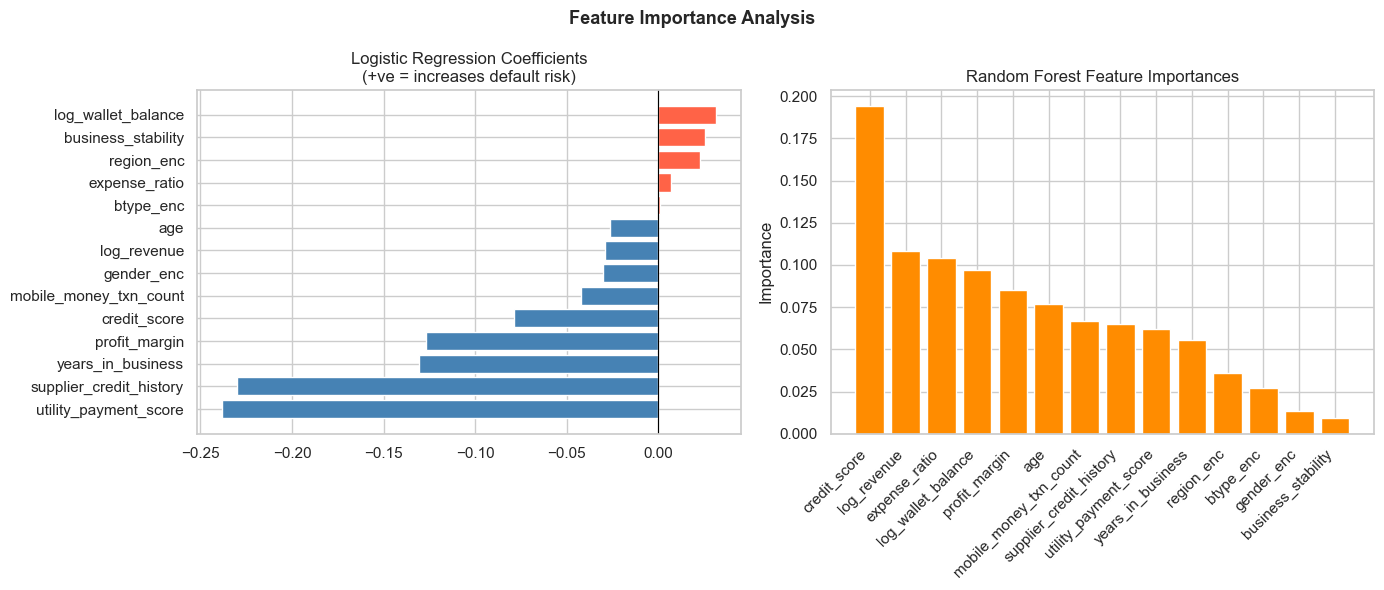

Top 5 features (Random Forest):
credit_score          0.1940
log_revenue           0.1081
expense_ratio         0.1039
log_wallet_balance    0.0971
profit_margin         0.0850
dtype: float64
Saved -> ../outputs/feature_importance.png


In [17]:
# Principle: Constructing for Verification, Minimising Complexity
# SAVES: ../outputs/feature_importance.png

IMPORTANCE_PATH = "../outputs/feature_importance.png"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance Analysis", fontsize=13, fontweight='bold')

lr_coef    = pd.Series(lr_model.coef_[0], index=FEATURES).sort_values()
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in lr_coef.values]
axes[0].barh(lr_coef.index, lr_coef.values, color=bar_colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("Logistic Regression Coefficients\n(+ve = increases default risk)")

rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
axes[1].bar(range(len(rf_imp)), rf_imp.values, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(len(rf_imp)))
axes[1].set_xticklabels(rf_imp.index, rotation=45, ha='right')
axes[1].set_title("Random Forest Feature Importances")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.savefig(IMPORTANCE_PATH, dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features (Random Forest):")
print(rf_imp.head(5).round(4))
print(f"Saved -> {IMPORTANCE_PATH}")

In [18]:
# Principle: Anticipating Change, Software Evolution (Area II)
# SAVES: ../data/final_scored_dataset_v2.csv

FINAL_PATH = "../data/final_scored_dataset_v2.csv"

X_all    = df[FEATURES]
X_all_sc = scaler.transform(X_all)

if needs_sc:
    all_probs = calib_model.predict_proba(X_all_sc)[:, 1]
else:
    all_probs = calib_model.predict_proba(X_all)[:, 1]

df['calibrated_default_prob'] = all_probs
df['credit_score_output']     = pd.Series(all_probs).apply(probability_to_score).values
df['decision']                = pd.Series(all_probs).apply(credit_decision).values

out_cols = [
    'vendor_id','age','gender','region','business_type',
    'years_in_business','monthly_revenue_xaf','monthly_expenses_xaf',
    'profit_margin','mobile_money_txn_count','avg_wallet_balance_xaf',
    'utility_payment_score','supplier_credit_history',
    'loan_defaulted','calibrated_default_prob',
    'credit_score_output','decision'
]
df[out_cols].to_csv(FINAL_PATH, index=False)

print(f"Decision distribution (all {len(df):,} records):")
print(df['decision'].value_counts(normalize=True).round(3))
print(f"\nCredit score: mean={df['credit_score_output'].mean():.0f}, std={df['credit_score_output'].std():.0f}")
print(f"\nSaved -> {FINAL_PATH}")
print(f"\nBest model: {best_name} | AUC = {best_auc:.4f}")
print("Pipeline complete.")

Decision distribution (all 8,700 records):
REJECT     0.362
APPROVE    0.323
REVIEW     0.315
Name: decision, dtype: float64

Credit score: mean=547, std=108

Saved -> ../data/final_scored_dataset_v2.csv

Best model: XGBoost | AUC = 0.7414
Pipeline complete.
